# Two coupled OU fields with correlated colored noise — Markovian embedding of a cross-correlated finite-$\tau_c$ drive

**Showcases:** **colored** (finite-$\tau_c$) noise that is also **cross-correlated** between two coupled fields. Each field $x,y$ obeys a quartic Langevin equation; the two are linearly coupled ($J$) and driven by Ornstein--Uhlenbeck noise whose white sources are correlated with coefficient $\rho$. Colored noise is **not** white, so the pipeline's preprocessor **Markovian-embeds** each channel as its own auxiliary OU field — visible below as the extra fields `dxi`, `dyi` — turning a 2-field colored problem into a 4-field white one. We plot the **cross-correlator** $C_{xy}(\tau)=\langle x(0)\,y(\tau)\rangle$, which is non-zero precisely *because* of $\rho$ and $J$. Run at **1-loop**.

$$\dot x = -\mu_1 x - \varepsilon_1 x^3 + J_1 y + \xi_x,\quad \dot y = -\mu_2 y - \varepsilon_2 y^3 + J_2 x + \xi_y,$$
$$\langle\xi_\alpha(t)\xi_\beta(t')\rangle = \frac{C_{\alpha\beta}}{\tau_c}\,e^{-|t-t'|/\tau_c},\qquad C=\begin{pmatrix}D_1 & \rho\sqrt{D_1 D_2}\\ \rho\sqrt{D_1 D_2} & D_2\end{pmatrix}.$$

## 0. Setup

In [1]:
%matplotlib inline
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
# depth-robust repo root: walk up until the 'api' package is found
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'api')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
os.chdir(os.path.join(_root, 'notebooks'))  # cwd=notebooks/ for simulations/ data paths
import daedalus as dd

## 1. The model

`dd.describe_model` prints the structure of the **embedded** system. The source theory declares two physical fields $x,y$ with three colored CGF terms ($C_{xx},C_{yy}$, and the cross term $C_{xy}\propto\rho$); the Markovian-embedding preprocessor has already run, so the field list shows two physical fluctuations (`dx`, `dy`) **and** two auxiliary OU noise fields (`dxi`, `dyi`). Those two extra fields *are* the embedding of the colored, correlated drive.

In [2]:
THEORY = 'ou_quartic_two_dim_color_corr'
model, mod = dd.load_theory(THEORY)
dd.describe_model(model, mod)
print('\nfields after embedding:', dd.field_names(model))

────────────────────────────────────────────────────────────────────────
  OU Quartic Two Dim Color-Corr
────────────────────────────────────────────────────────────────────────
Domain         : temporal ODE (time-only)
Fields         : x — variable1; y — variable2; xi — auxiliary OU noise (Markovian embedding of colored CGF on x); yi — auxiliary OU noise (Markovian embedding of colored CGF on y)
Response fields: xt, yt, xit, yit
Parameters     :
    mu1 = 1.0  (real)
    mu2 = 1.0  (real)
    eps1 = 0.05  (positive)
    eps2 = 0.05  (positive)
    J1 = 0.5  (real)
    J2 = 0.5  (real)
    D1 = 1.0  (positive)
    D2 = 1.0  (positive)
    rho = 0.5  (real)
    tauc = 10.0  (positive)
Mean-field saddle (solved by the pipeline): xstar, ystar, xistar, yistar
Governing eqn  : (Dt+mu1)*x = -eps1*x^3 + J1*y
Governing eqn  : (Dt+mu2)*y = -eps2*y^3 + J2*x
Action  S      : xt*((Dt+mu1)*x + eps1*x^3 - J1*y - xi) + yt*((Dt+mu2)*y + eps2*y^3 - J2*x - yi) + xit*((Dt + 1/tauc)*xi) + yit*((Dt + 1/tau

## 2. The pipeline → theoretical cumulants

One `dd.run` drives the whole MSR-JD chain on the embedded 4-field system. We request the **cross-correlator** with `external_fields=[('dx', 1), ('dy', 1)]` — one external leg on each physical field. (Both legs are physical; the auxiliary `dxi`/`dyi` are never external.) The plot is **theory only**; the simulation is added in §3. We keep $\mu\,\tau_c\neq 1$ so the embedded propagator poles ($\mu$ and $1/\tau_c$) stay distinct.

In [3]:
cfg = dd.Config(
    k=2, max_ell=1,                          # C_xy(τ), tree + 1-loop
    external_fields=[('dx', 1), ('dy', 1)],  # CROSS-correlator ⟨x y⟩
    parameters={'mu1': 1.0, 'mu2': 1.0, 'eps1': 0.02, 'eps2': 0.02,
                'J1': 0.3, 'J2': 0.3, 'D1': 1.0, 'D2': 1.0,
                'rho': 0.5, 'tauc': 2.0},
    tau_grid=(-6.0, 6.0, 25),
    parallel=False,                          # serial (no fork in a notebook)
#   ─── optional · uncomment any (swap the leading # for a space) · dd.config_options() lists all ───
#   output='moment',              # 'cumulant'(default) | 'moment' | 'central_moment'
#   kpoint_base_lags=[0.0, 0.0],  # k≥3 temporal: fix the non-swept legs (slices cross here)
#   kpoint_full_grid=True,        # k≥3 temporal: full (k−1)-D tensor C(τ₁,…) vs axis slices
#   dyson_order=2, reference_diffusion=1.0,   # coupled unequal-D Dyson dressing
#   fixed_point_index=0,          # multi-root saddle: which stable root (0, 1, …)
#   mf_dae_n_starts=64, mf_dae_seed_box=None, # saddle solver: multi-start / seed box
#   n_workers=4,                  # worker count (spatial threads; macOS temporal: outside Jupyter)
#   verbose=True,                 # print backend progress
#   show_orders='incremental',    # 'cumulative'(default) | 'incremental' | 'total'
#   logy=True,                    # log-scale the y axis
#   components=None,              # which (i,j)/slice to draw (multi-field)
#   figsize=(7.5, 4.6),           # matplotlib figure size
#   title='...',                  # override the plot title
#   save='fig.png',               # path to savefig
)


theory : 'OU Quartic Two Dim Color-Corr'
k      : 2    max_ell : 1
fields : ['x', 'y', 'xi', 'yi']   spatial_dim : 0


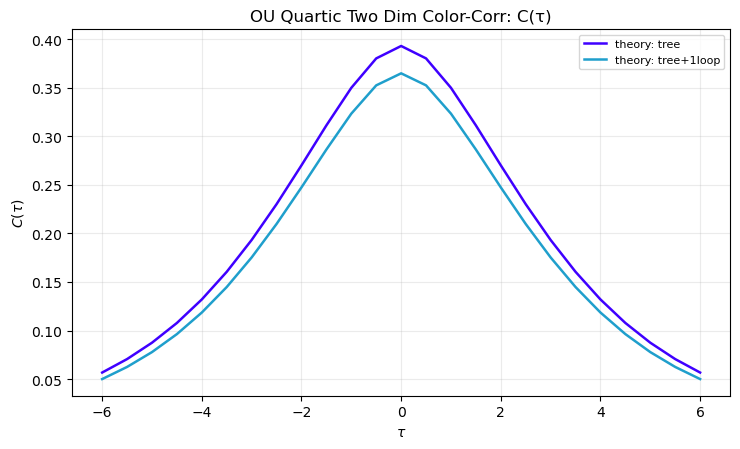

In [4]:
res = dd.run(model, cfg, mod)
print(dd.summary(res))
dd.plot_cumulant(res, cfg, model)   # theory only
plt.show()

## 3. Independent simulation

A direct integration of the coupled colored-noise SDEs — written from scratch, no reference to the diagrammatics. Each auxiliary OU noise process is **exactly** discretised (the closed-form linear-OU update, valid at any $dt/\tau_c$), and the two white drivers are correlated by a Cholesky factor of $\begin{psmallmatrix}1&\rho\\\rho&1\end{psmallmatrix}$. We estimate the cross-correlator $C_{xy}$ (leg 0 on $x$, leg 1 on $y$) and overlay it.

sim took 11.0s  (3 runs × T=3e+05)
C_xy(0):  tree = 0.3930   tree+1-loop = 0.3648   sim = 0.3687 ± 0.0010


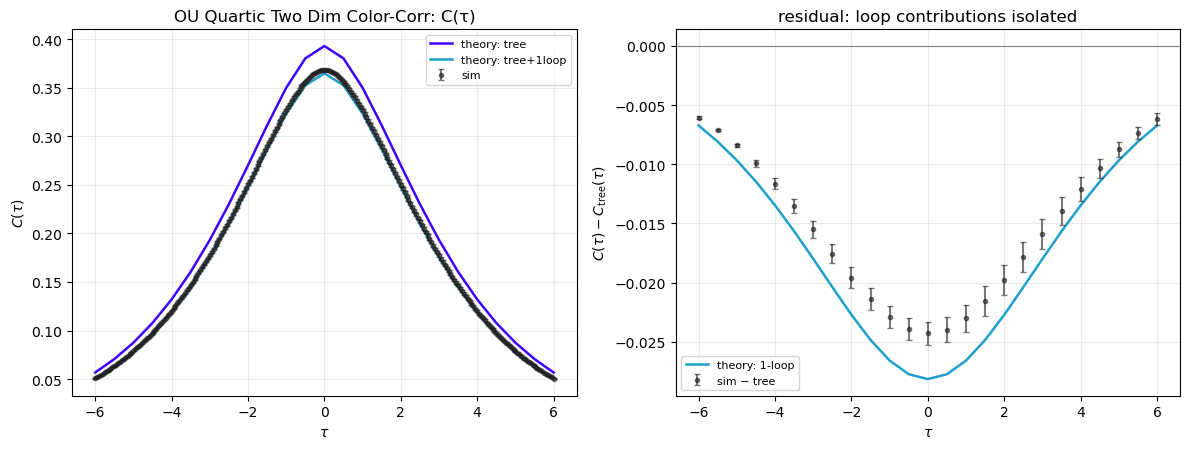

In [5]:
# Independent SDE simulation (coupled, exact-OU colored, ρ-correlated) — NOT the pipeline.
from simulations.ou_langevin_sim_numba import sim_ou_quartic_two_dim_color_corr_numba
from simulations.cumulant_estimator import estimate_kpoint_slices
fp = res['_resolved']['parameters']          # same physics as the theory run
# Cast to plain Python floats — under the Sage kernel the resolved params are
# Sage ring elements, which numba's njit cannot type.
g = lambda key: float(fp[key])
mu1, mu2 = g('mu1'), g('mu2'); eps1, eps2 = g('eps1'), g('eps2')
J1, J2   = g('J1'),  g('J2');  D1, D2     = g('D1'),   g('D2')
tauc, rho = g('tauc'), g('rho')

# Discretization.  dt ≪ tau_c and ≪ 1/mu; bin FINELY so the bin-averaged
# cross-covariance is effectively the instantaneous C_xy.
dt_sim, dt_bin = float(0.005), float(0.05)
T_sim          = float(3.0e5)              # ~1-min run for clean error bars
N_RUNS         = int(3)
tau_max        = float(np.max(np.abs(res['tau_grid'])))
n_steps        = int(T_sim / dt_sim)
bin_size_steps = int(max(round(float(dt_bin / dt_sim)), 1))
dt_bin_eff     = float(bin_size_steps * dt_sim)
n_bins         = int(n_steps // bin_size_steps)
max_lag_bins   = int(tau_max / dt_bin_eff)

# k-aware estimator: leg 0 → field x (pop index 0), leg 1 → field y (index 1).
k         = int(res['_resolved']['k'])
base      = list(cfg.kpoint_base_lags) if cfg.kpoint_base_lags else [0.0]*(k-1)
base_bins = [int(round(b / dt_bin_eff)) for b in base]
pop_indices = [0, 1]            # x, y
field_types = ['dv', 'dv']

x_init, y_init = float(0.0), float(0.0)   # float() so the Sage kernel's preparser
                                          # doesn't hand numba a RealLiteral it can't type
args = (mu1, mu2, eps1, eps2, J1, J2, D1, D2, tauc, rho, x_init, y_init)
_ = sim_ou_quartic_two_dim_color_corr_numba(
    int(1000), dt_sim, *args, bin_size_steps, int(100), int(0))   # JIT warmup
rng_base = int(np.random.SeedSequence().generate_state(1)[0]) % (2**31)
C_runs = []
t0 = time.perf_counter()
for r in range(N_RUNS):
    bins = sim_ou_quartic_two_dim_color_corr_numba(
        n_steps, dt_sim, *args, bin_size_steps, n_bins, int(rng_base + r))  # (2, n_bins)
    tau_sim, Cj = estimate_kpoint_slices(
        dt_bin_eff, pop_indices, field_types, base_bins,
        int(max_lag_bins), voltage_bins=bins)                # Cj: (k-1, n_tau)
    C_runs.append(np.asarray(Cj).real)
C_arr = np.array(C_runs)
C_sim = C_arr.mean(axis=0)
C_err = C_arr.std(axis=0, ddof=1) / np.sqrt(N_RUNS)
sim   = {'tau': tau_sim, 'C': C_sim, 'C_err': C_err}
print('sim took %.1fs  (%d runs × T=%.0g)' % (time.perf_counter() - t0, N_RUNS, T_sim))

i0 = int(np.argmin(np.abs(np.asarray(res['tau_grid']))))
js = int(np.argmin(np.abs(tau_sim)))
C0_tree = np.real(res['C_tau_by_ell'][0])[i0]
C0_loop = np.real(res['C_tau'])[i0]
print('C_xy(0):  tree = %.4f   tree+1-loop = %.4f   sim = %.4f ± %.4f'
      % (C0_tree, C0_loop, C_sim[0][js], C_err[0][js]))
dd.plot_cumulant(res, cfg, model, sim=sim, residual=True)
plt.show()

## Summary

The cross-correlator $C_{xy}(\tau)$ is non-zero only because the two noise channels are correlated ($\rho$) and the fields are coupled ($J$); its shape is set by the **colored** (finite-$\tau_c$, rise-and-decay) kernel rather than a white spike, and it is asymmetric in $\tau$ because the coupling is directional. The whole calculation runs on the **embedded** white-noise system (the auxiliary `dxi`, `dyi` fields), and asking for `('dx','dy')` recovers the physical cross-correlation. The 1-loop self-energy from the cubic vertices moves the theory off the tree value into agreement with the direct correlated-colored-noise simulation. The same `dd.run` with `('dx','dx')` would instead give the auto-correlator $C_{xx}$.